In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [8]:

merged = pd.read_csv("../data/merged.csv")
print(merged.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures_mat', 'schoolsup', 'famsup', 'paid_mat', 'activities',
       'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime',
       'goout', 'Dalc', 'Walc', 'health', 'absences_mat', 'G1_mat', 'G2_mat',
       'G3_mat', 'failures_por', 'paid_por', 'absences_por', 'G1_por',
       'G2_por', 'G3_por'],
      dtype='object')


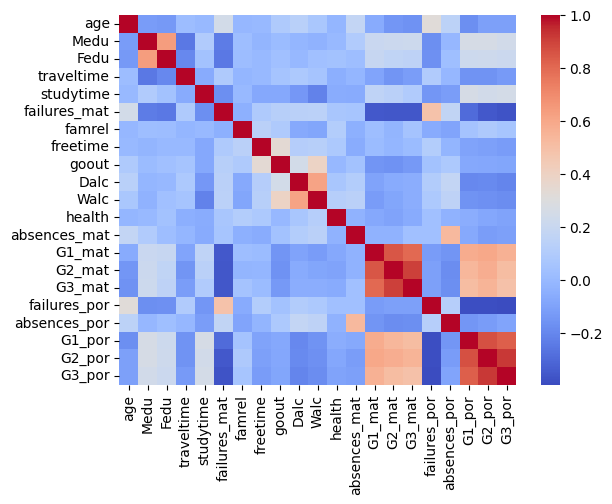

In [9]:
# heatmap sur les var quantitatives
sns.heatmap(merged.corr(numeric_only=True),cmap="coolwarm")
plt.show()

# On remarque qu'il n'y a pas de corrélation transcendante entre les variables numériques
# Seules les notes Gi le sont ce qui parait logique
# On remarque aussi que Medu et Fedu ainsi que Walc et Dalc le sont ce qui est plutôt logique 
# (quelqu'un qui boit de l'alcool le week-end a plus de chance d'en boire la semaine et inversement/ 
# il est aussi probable que les catégories sociaux professionnelles des parents soient similaire)

# On se demande donc si l'analyse PCA sera pertinente si les variables sont peu corrélés (Difficile pour un axe de capter beuacoup d'inertie)

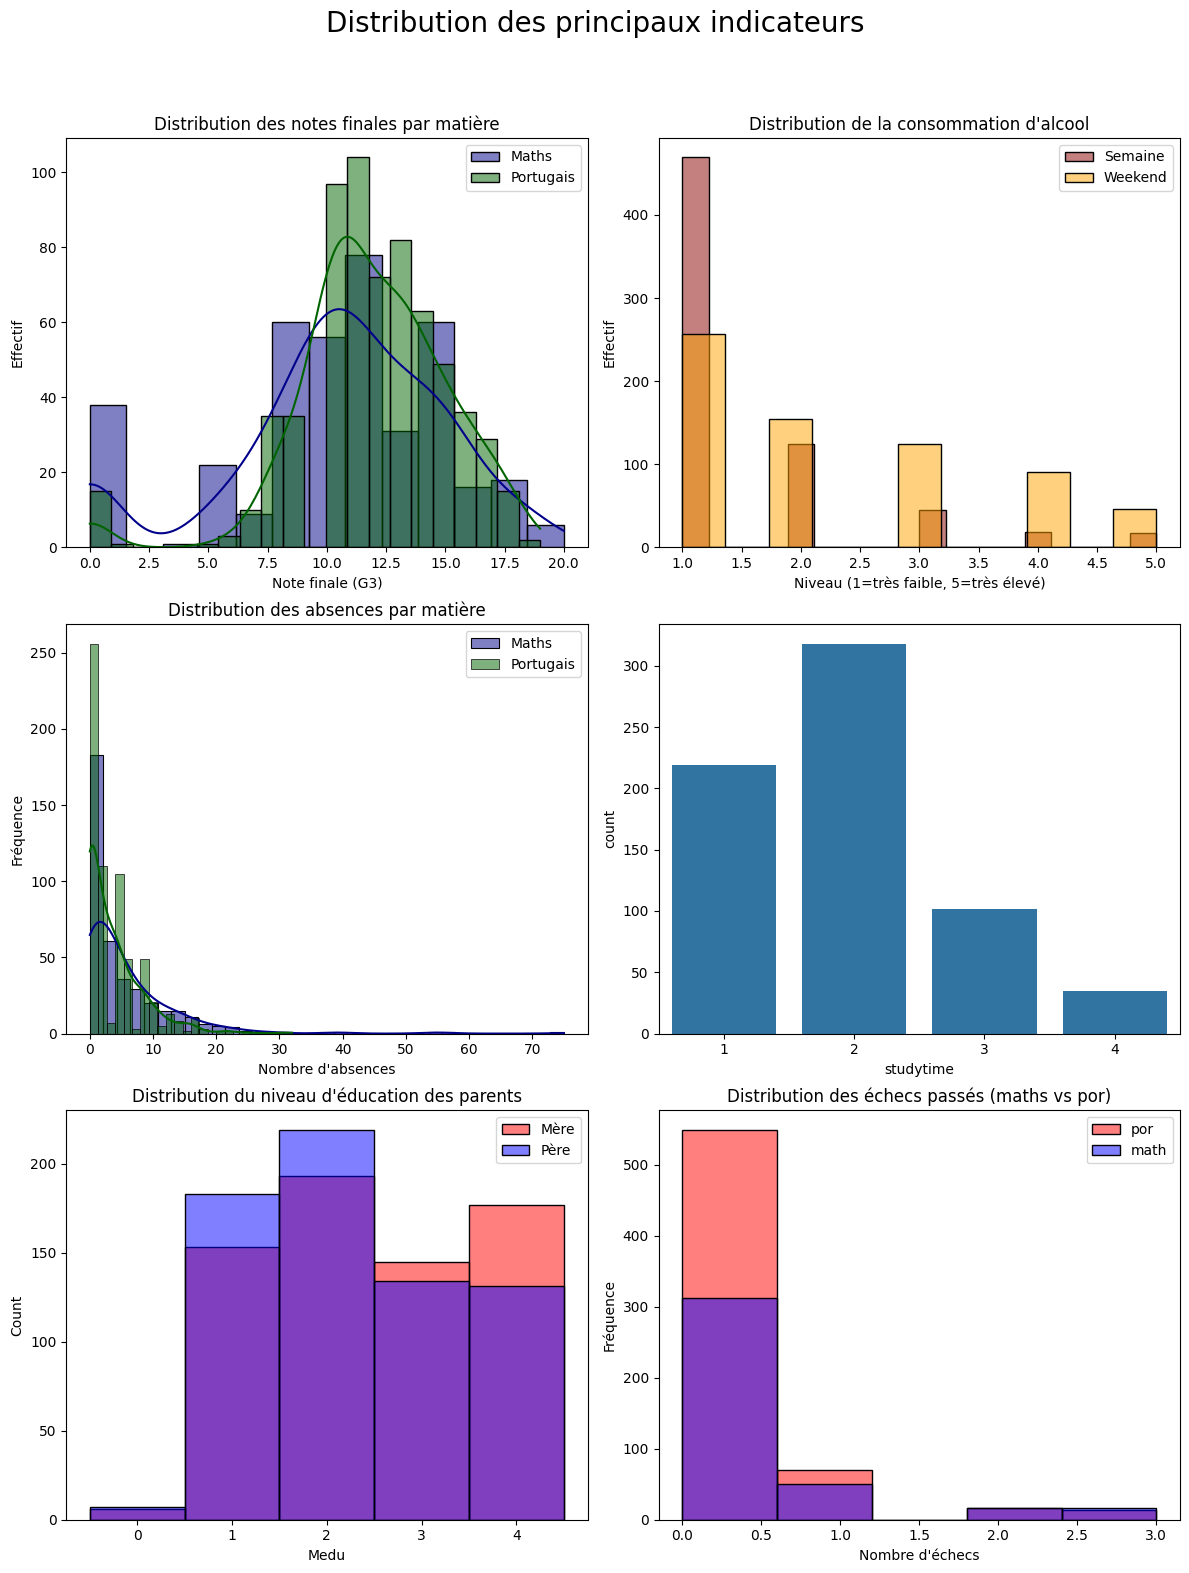

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(12, 16))
fig.suptitle('Distribution des principaux indicateurs', fontsize=20)

# Notes finales math vs portugais
sns.histplot(merged['G3_mat'].dropna(), ax=axes[0, 0], color='darkblue', label='Maths', kde=True, stat='count', alpha=0.5)
sns.histplot(merged['G3_por'].dropna(), ax=axes[0, 0], color='darkgreen', label='Portugais', kde=True, stat='count', alpha=0.5)
axes[0, 0].set_title('Distribution des notes finales par matière')
axes[0, 0].set_xlabel('Note finale (G3)')
axes[0, 0].set_ylabel('Effectif')
axes[0, 0].legend()

# Les notes de mat et por semblent toutes les 2 suivre un genre de loi normal mais les notes de portugais sont meilleus en moyenne qu'en math

# Consommation d'alcool
sns.histplot(merged['Dalc'], ax=axes[0, 1], color='darkred', label='Semaine', stat='count', alpha=0.5)
sns.histplot(merged['Walc'], ax=axes[0, 1], color='orange', label='Weekend', stat='count', alpha=0.5)
axes[0, 1].set_title("Distribution de la consommation d'alcool")
axes[0, 1].set_xlabel('Niveau (1=très faible, 5=très élevé)')
axes[0, 1].set_ylabel('Effectif')
axes[0, 1].legend()

# Rappel
# Dalc - workday alcohol consumption (numeric: from 1 - very low to 5 - very high)
# Walc - weekend alcohol consumption (numeric: from 1 - very low to 5 - very high)
# La plupart des etudiants consomment moins d'alcool en semaine que le week-end ce qui est vraisemblable




# Absences math vs portugais
sns.histplot(merged['absences_mat'].dropna(), kde=True, ax=axes[1, 0], color='darkblue', label='Maths')
sns.histplot(merged['absences_por'].dropna(), kde=True, ax=axes[1, 0], color='darkgreen', label='Portugais')
axes[1, 0].set_title('Distribution des absences par matière')
axes[1, 0].set_xlabel('Nombre d\'absences')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].legend()

# On remarque qu'il y a beaucoup plus d'abscences ponctuelles en cours de portugais qu'en math
# Cependant si on s'interesse à nb_absence > 10 il semble y en avoir plus math
# On peut supposer que le portugais est un cours pas forcement pris au sérieux ( les élèvent séchent tous quelques cours)
# Et que pour les maths il y a par contre plus d'élèves qui abandonnent la matière et qui donc ont un taux d'abscence élevé

# Temps d'étude hebdomadaire
sns.countplot(x=merged['studytime'], ax=axes[1, 1])
axes[2, 1].set_title('Temps d\'étude hebdomadaire')

# Rappel studytime - weekly study time (numeric: 1 - <2 hours, 2 - 2 to 5 hours, 3 - 5 to 10 hours, or 4 - >10 hours)
# La majorité des étudiants étudient moins de 5h par semaine


# Éducation des parents
sns.histplot(merged['Medu'], bins=5, discrete=True, ax=axes[2, 0],
             color='red', alpha=0.5, label='Mère')

sns.histplot(merged['Fedu'], bins=5, discrete=True, ax=axes[2, 0],
             color='blue', alpha=0.5, label='Père')

axes[2, 0].legend()
axes[2, 0].set_title('Distribution du niveau d\'éducation des parents')

# Rappel Medu - mother's education (numeric: 0 - none, 1 - primary education (4th grade), 2 – 5th to 9th grade, 3 – secondary education or 4 – higher education)
#  Fedu - father's education (numeric: 0 - none, 1 - primary education (4th grade), 2 – 5th to 9th grade, 3 – secondary education or 4 – higher education)
# Les mères semblent plus éduquée académiquements que les pères


# Échecs passés
sns.histplot(merged['failures_por'], bins=5, discrete=False, ax=axes[2, 1],
             color='red', alpha=0.5, label='por')

sns.histplot(merged['failures_mat'], bins=5, discrete=False, ax=axes[2, 1],
             color='blue', alpha=0.5, label='math')
axes[2, 1].set_title('Distribution des échecs passés (maths vs por)')
axes[2, 1].set_xlabel('Nombre d\'échecs')
axes[2, 1].set_ylabel('Fréquence')
axes[2, 1].legend()

# Le nombre de 'échecs semble similaire mais il y a un effet taille car il y a plus d'élèves en portugais qu'en math
# En voit donc qu'il y a plus d'echecs en math si on recoupe par les effectifs dans chaque matière
# Les échecs semblent rares, la plupart n'en ont aucun


plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

In [11]:
print(merged['failures_mat'])
print(merged['failures_mat'].dtype)
print(merged['failures_mat'].value_counts(dropna=False))

0      1.0
1      NaN
2      2.0
3      0.0
4      0.0
      ... 
669    NaN
670    0.0
671    NaN
672    2.0
673    3.0
Name: failures_mat, Length: 674, dtype: float64
float64
failures_mat
0.0    312
NaN    279
1.0     50
2.0     17
3.0     16
Name: count, dtype: int64
